# Week 2 — Task 2: House Price Prediction with Linear Regression

**Neurofive ML Track**

Goal: predict a **number** (median house value) instead of a category — this
is a **regression** problem, unlike the classification task from before.

Dataset: the California Housing dataset (block-group level housing data from
the 1990 census — the standard modern replacement for the deprecated Boston
Housing dataset). Each row is a "block group" (a small geographic area), not
a single house, but the target (`median_house_value`) and features work the
same way for this exercise.


## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('housing.csv')
df.shape

(20640, 10)

In [2]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## 2. Handling missing values

Only `total_bedrooms` has missing values (207 out of 20,640 rows, about 1%).
Since it's such a small fraction, we fill it with the median rather than
dropping rows -- dropping would lose good data in the other columns of those
rows for almost no benefit.


In [4]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum().sum()  # should be 0

np.int64(0)

## 3. Selecting features

The dataset has several candidate columns. We select the features most
plausibly linked to price for a first, simple model:

- **`median_income`** -- income of the area strongly relates to what people can afford to pay for housing
- **`total_rooms`** -- a proxy for the size/scale of homes in the area
- **`housing_median_age`** -- older vs. newer housing stock can affect value
- **`latitude`** and **`longitude`** -- location is one of the biggest drivers of real estate price (coastal vs. inland areas differ a lot in California)

We leave out `total_bedrooms`, `population`, `households`, and
`ocean_proximity` for this first pass -- they either overlap heavily with the
features already chosen or need extra encoding, and the task asks for a
focused 3-5 feature model.


In [5]:
selected_features = ['median_income', 'total_rooms', 'housing_median_age', 'latitude', 'longitude']

X = df[selected_features]
y = df['median_house_value']

X.head()

,median_income,total_rooms,housing_median_age,latitude,longitude
0,8.3252,880.0,41.0,37.88,-122.23
1,8.3014,7099.0,21.0,37.86,-122.22
2,7.2574,1467.0,52.0,37.85,-122.24
3,5.6431,1274.0,52.0,37.85,-122.25
4,3.8462,1627.0,52.0,37.85,-122.25


## 4. Train/test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 16512 rows
Test set size: 4128 rows


## 5. Train the Linear Regression model

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")

coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_
})
coef_df

Model trained.


,Feature,Coefficient
0,median_income,37535.980826
1,total_rooms,3.383466
2,housing_median_age,1167.869663
3,latitude,-43887.440531
4,longitude,-44682.959059


Each coefficient tells us how much `median_house_value` changes for a
one-unit increase in that feature, holding the others constant. For example,
a positive `median_income` coefficient means higher-income areas are
predicted to have higher home values, all else equal.


## 6. Predictions and evaluation

In [8]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"R2 score: {r2:.4f}")

RMSE: 73,793.10
R2 score: 0.5844


**RMSE (Root Mean Squared Error)** tells us, on average, how far off our
predictions are from the actual house values, in the same units as the
target (dollars). A lower RMSE means more accurate predictions.

**R2 score** tells us what proportion of the variation in house prices our
model explains, on a scale from 0 to 1 (it can go negative for a very poor
model). Higher is better -- 1.0 would mean perfect predictions.


## 7. Predicted vs. actual scatter plot

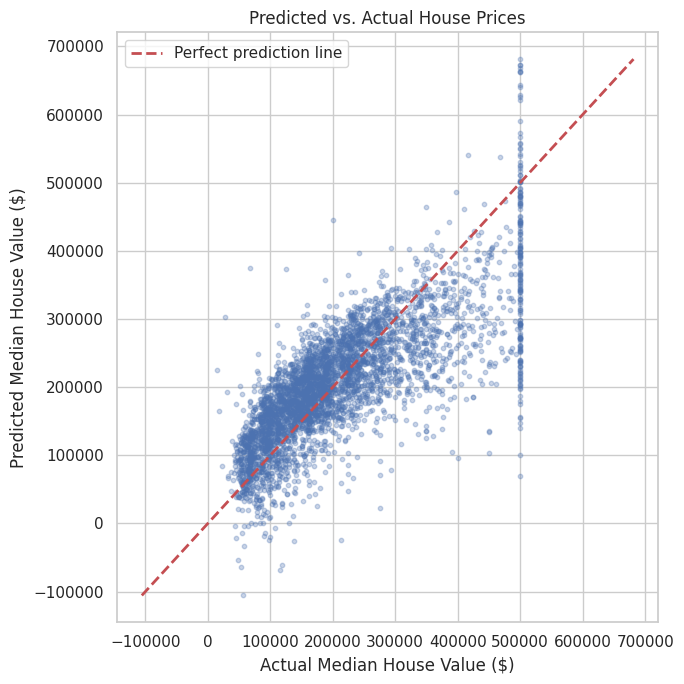

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='#4C72B0')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction line')

plt.xlabel('Actual Median House Value ($)')
plt.ylabel('Predicted Median House Value ($)')
plt.title('Predicted vs. Actual House Prices')
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight')
plt.show()

**Reading this plot:** the dashed red line represents perfect predictions
(where predicted = actual). Points close to that line are good predictions;
points far above or below it are cases the model got noticeably wrong. Here,
the points cluster loosely around the line for mid-range prices but spread
out more at the high end -- the model tends to underestimate the most
expensive homes, and there's a visible flat ceiling around $500,000, which
comes from the dataset itself (house values were capped at that amount during
data collection).


## 8. Residual plot (extra diagnostic)

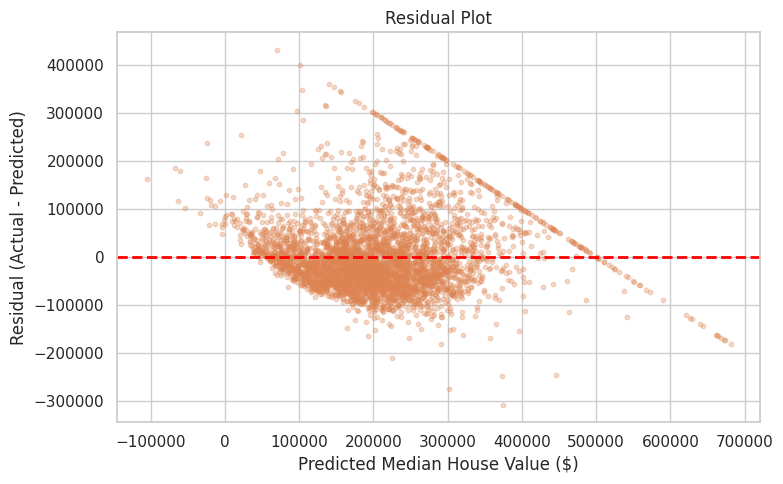

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, s=10, color='#DD8452')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Median House Value ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('residual_plot.png', bbox_inches='tight')
plt.show()

Residuals should ideally scatter randomly around zero with no pattern. Here
there's a visible fan/curve shape, which tells us a plain linear model isn't
fully capturing the relationship -- a sign that a more flexible model
(e.g., polynomial features, or a tree-based model) could improve on this.


## 9. What does the R2 score mean, in plain English?

Our model's R2 score means that roughly **58.4% of the
differences in house prices across neighborhoods can be explained by the five
factors we gave the model** -- income level, number of rooms, house age, and
location (latitude/longitude). The remaining gap is due to things the model
doesn't know about, like the condition of a specific home, school quality,
crime rates, or other local features not included here. In short: the model
gives a reasonable ballpark estimate of what a house in an area *should* be
worth based on a few basic facts, but it isn't precise enough to price an
individual home exactly -- think of it as a rough neighborhood-level estimate,
not an appraisal.


## 10. Summary

- Used the California Housing dataset (20,640 block groups).
- Filled the small number of missing `total_bedrooms` values with the median.
- Selected 5 features: `median_income`, `total_rooms`, `housing_median_age`, `latitude`, `longitude`.
- Trained a `LinearRegression` model with an 80/20 train/test split.
- Evaluated with RMSE and R2, and visualized predicted vs. actual prices plus a residual plot.
- `median_income` and location (`latitude`/`longitude`) are the most influential features, consistent with real-world intuition about real estate pricing.
